### **Data Cleaning con Pandas**

#### **1 - Cargamos las librerias que vamos a utilizar**

In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt

#### **2 - Importamos el archivo CSV**

In [3]:
df_netflix = pd.read_csv('netflix_titles.csv')

df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [99]:
df_netflix.shape

(8807, 12)

#### **3 - Importar el modulo de **`calidad_datos`** para analizar datos estadisticos, nulos y ceros del Dataframe**

In [3]:
from calidad_datos import calidad_datos

d = calidad_datos(df_netflix)
d = np.round(d, 2)
d

,tipo,nulos,porc_nulos,ceros,porc_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,limit_inf,limit_sup,outliers
release_year,int64,0,0.00,0,0.0,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0,2000.951229,2027.409166,562
show_id,object,0,0.00,0,0.0,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
type,object,0,0.00,0,0.0,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
title,object,0,0.00,0,0.0,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
director,object,2634,29.91,0,0.0,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
cast,object,825,9.37,0,0.0,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
country,object,831,9.44,0,0.0,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
date_added,object,10,0.11,0,0.0,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
rating,object,4,0.05,0,0.0,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
duration,object,3,0.03,0,0.0,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


#### **4 - Filtrar los datos vacios**

In [ ]:
df_netflix.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Visualizamos los `indices` que poseen valores `NaN` en la columna `director`

In [ ]:
no_director = df_netflix[df_netflix['director'].isnull()].index
no_director

Index([   1,    3,    4,   10,   14,   15,   17,   19,   21,   25,
       ...
       8775, 8780, 8783, 8784, 8785, 8795, 8796, 8797, 8800, 8803],
      dtype='int64', length=2634)

##### `Forma 1`

Filtramos todos los datos que no tengan director, dejando solo asi aquellas series y peliculas que si tengan este dato:

In [ ]:
df_netflix = df_netflix[df_netflix['director'].str.len() > 0]

##### `Forma 2`

Filtramos todos los datos que no tengan director, dejando solo asi aquellas series y peliculas que si tengan este dato:

In [ ]:
# Lo mismo ---> df_netflix[~df_netflix['director'].isnull()]
df_netflix  = df_netflix[~df_netflix.director.isnull()]

##### `Forma 3` - Utilizando RegEx

`na=True` significa que devolverá los valroes NaN de la columna seleccionada

In [ ]:
#df_netflix[~df_netflix['director'].str.contains(r'^(?:\s+)?$', na=True, regex=True)]
#df_netflix[~df_netflix['director'].str.contains(r'^(?:\s+)', na=True, regex=True)]
df_netflix = df_netflix[~df_netflix['director'].str.contains(r'(?:\s+)', na=True, regex=True)]

##### `Forma 4` - Utilizando dropna()

In [4]:
# dropear valores null solo de la columna "director"
df_netflix = df_netflix.dropna(subset=['director'])
df_netflix.shape

(6173, 12)

In [ ]:
# dropear valores null de todas las columnas
df_netflix.dropna(axis=0, how="any", inplace=True)

#### **5 - Filtrar datos mal ingresados**

Revisemos las columnas de nuestro dataframe (dar por entendido que realizamos el paso de eliminar solo las filas que posean datos `NaN` en la columna `director`):

In [4]:
df_netflix.shape

(6173, 12)

In [5]:
df_netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
df_netflix.columns.values

array(['show_id', 'type', 'title', 'director', 'cast', 'country',
       'date_added', 'release_year', 'rating', 'duration', 'listed_in',
       'description'], dtype=object)

In [7]:
df_netflix.shape

(6173, 12)

In [8]:
df_netflix.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Revisamos los datos de cada columna:

##### Columna **`show_id`**

In [9]:
df_netflix['show_id'].unique()

array(['s1', 's3', 's6', ..., 's8805', 's8806', 's8807'], dtype=object)

In [10]:
df_showid = df_netflix[df_netflix['show_id'].str.contains(r'(^s)', na=False, regex=True)]
df_showid.shape

C:\Users\Alfonso\AppData\Local\Temp\ipykernel_17292\3445534726.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_showid = df_netflix[df_netflix['show_id'].str.contains(r'(^s)', na=False, regex=True)]


(6173, 12)

##### Columna **`type`**

In [11]:
df_netflix['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

##### Columna **`country`**

In [12]:
df_netflix['country'].unique()

array(['United States', nan,
       'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
       'United Kingdom', 'Germany, Czech Republic', 'India',
       'United States, India, France', 'China, Canada, United States',
       'South Africa, United States, Japan', 'Japan', 'Nigeria',
       'Spain, United States', 'France', 'United Kingdom, United States',
       'United Kingdom, Australia, France',
       'United Kingdom, Australia, France, United States',
       'United States, Canada', 'Germany, United States',
       'South Africa, United States', 'United States, Mexico',
       'United States, Italy, France, Japan',
       'United States, Italy, Romania, United Kingdom',
       'Australia, United States', 'Argentina, Venezuela',
       'United States, United Kingdom, Canada', 'China, Hong Kong',
       'Canada', 'Hong Kong', 'United States, China, Hong Kong',
       'Italy, United States', 'United States, Germany',
       'United Kingdom, Canada, United States

##### Columna **`date_added`**

In [13]:
df_netflix['date_added'].unique()

array(['September 25, 2021', 'September 24, 2021', 'September 23, 2021',
       ..., 'December 6, 2018', 'March 9, 2016', 'January 11, 2020'],
      dtype=object)

Dado que este dato mantiene un patrón **`Mes Dia, Año`**, podemos escribir un patrón que solo nos devuelva los elementos que `NO` poseen el año al final de ese string:

In [14]:
df_date_added = df_netflix[~df_netflix['date_added'].str.contains(r'.+(\d{4}$)', na=False, regex=True)]
df_date_added.shape

C:\Users\Alfonso\AppData\Local\Temp\ipykernel_17292\3745071170.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_date_added = df_netflix[~df_netflix['date_added'].str.contains(r'.+(\d{4}$)', na=False, regex=True)]


(0, 12)

##### Columna **`release_year`**

In [15]:
df_netflix['release_year'].unique()

array([2020, 2021, 1993, 1996, 1998, 1997, 2010, 2013, 2017, 1975, 1978,
       1983, 1987, 2012, 2001, 2002, 2003, 2004, 2011, 2008, 2009, 2007,
       2005, 2006, 2018, 2019, 1994, 2015, 1982, 1989, 2014, 1990, 1991,
       1999, 2016, 1986, 1984, 1980, 1961, 2000, 1995, 1985, 1992, 1976,
       1959, 1988, 1981, 1972, 1964, 1954, 1979, 1958, 1956, 1963, 1970,
       1973, 1960, 1974, 1966, 1971, 1962, 1969, 1977, 1967, 1968, 1965,
       1945, 1946, 1942, 1955, 1944, 1947, 1943], dtype=int64)

##### Columna **`rating`**

In [16]:
df_netflix['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'R', 'TV-G',
       'TV-Y7', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR',
       'TV-Y7-FV', 'UR', nan], dtype=object)

Si revisamos los elementos de la columna "`rating`" vemos que hay 3 datos mal ingresados [`'74 min'`, `'84 min'`, `'66 min'`] que corresponden a la columna "`duration`":

In [4]:
df_netflix[df_netflix['rating'].str.contains(r'(min$)', na=False, regex=True)]

C:\Users\Alfonso\AppData\Local\Temp\ipykernel_4668\551959569.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_netflix[df_netflix['rating'].str.contains(r'(min$)', na=False, regex=True)]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


- Podemos crear un nuevo dataframe sin esas 3 filas. 

In [4]:
df_netflix.shape

(6173, 12)

In [5]:
df_netflix = df_netflix[~df_netflix['rating'].str.contains(r'(?:min$)', na=False, regex=True)]
df_netflix.shape

(6170, 12)

##### Columna **`duration`**

In [7]:
df_netflix['duration'].unique()

array(['90 min', '1 Season', '91 min', '125 min', '9 Seasons', '104 min',
       '127 min', '67 min', '94 min', '161 min', '61 min', '166 min',
       '147 min', '103 min', '97 min', '106 min', '111 min', '110 min',
       '105 min', '96 min', '124 min', '116 min', '98 min', '23 min',
       '115 min', '122 min', '99 min', '88 min', '100 min', '102 min',
       '93 min', '95 min', '85 min', '83 min', '113 min', '13 min',
       '182 min', '48 min', '145 min', '87 min', '92 min', '80 min',
       '117 min', '128 min', '119 min', '143 min', '114 min', '118 min',
       '108 min', '63 min', '121 min', '142 min', '154 min', '120 min',
       '82 min', '109 min', '101 min', '86 min', '229 min', '76 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '135 min',
       '136 min', '165 min', '150 min', '133 min', '70 min', '84 min',
       '140 min', '78 min', '2 Seasons', '64 min', '59 min', '139 min',
       '69 min', '148 min', '189 min', '141 min', '130 min', '138 min',
    

Dado que este dato mantiene un patrón "**cantidad `Season(s)`**" o "**minutos `min`**", podemos escribir un patrón que solo nos devuelva los elementos que posean la forma `NUMERO PALABRA`:

In [8]:
df_duration = df_netflix[df_netflix['duration'].str.contains(r'(\d{1,})\s([a-z_A-Z]+)', na=False, regex=True)]
df_duration.shape

C:\Users\Alfonso\AppData\Local\Temp\ipykernel_3724\1987221988.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_duration = df_netflix[df_netflix['duration'].str.contains(r'(\d{1,})\s([a-z_A-Z]+)', na=False, regex=True)]


(6170, 12)

Otra opción, es `dividir` la columna `duration`:

In [10]:
df_netflix['duration'].str.split()

0         [90, min]
2       [1, Season]
5       [1, Season]
6         [91, min]
7        [125, min]
           ...     
8801      [96, min]
8802     [158, min]
8804      [88, min]
8805      [88, min]
8806     [111, min]
Name: duration, Length: 6170, dtype: object

In [22]:
df_netflix['duration'].str.split(expand=True)

,0,1
0,90,min
2,1,Season
5,1,Season
6,91,min
7,125,min
...,...,...
8801,96,min
8802,158,min
8804,88,min
8805,88,min


Y revisar cada columna:

In [9]:
df_netflix['duration'].str.split().str[0]

0        90
2         1
5         1
6        91
7       125
       ... 
8801     96
8802    158
8804     88
8805     88
8806    111
Name: duration, Length: 6170, dtype: object

In [23]:
df_netflix['duration'].str.split(expand=True)[0]

0        90
2         1
5         1
6        91
7       125
       ... 
8801     96
8802    158
8804     88
8805     88
8806    111
Name: 0, Length: 6170, dtype: object

Verificar que la primera columna posee solo numeros:

In [11]:
df_netflix['duration'].str.split().str[0].to_list()

['90',
 '1',
 '1',
 '91',
 '125',
 '9',
 '104',
 '1',
 '127',
 '91',
 '67',
 '94',
 '1',
 '161',
 '61',
 '166',
 '147',
 '103',
 '97',
 '106',
 '111',
 '110',
 '105',
 '96',
 '124',
 '116',
 '98',
 '91',
 '23',
 '115',
 '1',
 '122',
 '99',
 '99',
 '88',
 '100',
 '102',
 '93',
 '96',
 '95',
 '85',
 '97',
 '95',
 '83',
 '103',
 '113',
 '13',
 '182',
 '106',
 '48',
 '145',
 '145',
 '93',
 '106',
 '147',
 '87',
 '96',
 '95',
 '92',
 '91',
 '90',
 '97',
 '80',
 '1',
 '117',
 '128',
 '90',
 '1',
 '119',
 '110',
 '143',
 '119',
 '114',
 '94',
 '106',
 '99',
 '118',
 '115',
 '95',
 '115',
 '108',
 '63',
 '117',
 '121',
 '142',
 '113',
 '154',
 '95',
 '108',
 '120',
 '100',
 '82',
 '124',
 '114',
 '104',
 '94',
 '94',
 '1',
 '93',
 '97',
 '109',
 '88',
 '101',
 '105',
 '102',
 '101',
 '103',
 '106',
 '118',
 '86',
 '121',
 '229',
 '76',
 '95',
 '98',
 '89',
 '120',
 '110',
 '83',
 '121',
 '105',
 '94',
 '156',
 '112',
 '95',
 '107',
 '114',
 '129',
 '86',
 '97',
 '125',
 '107',
 '127',
 '128',


In [24]:
df_netflix['duration'].str.split(expand=True)[0].unique()

array(['90', '1', '91', '125', '9', '104', '127', '67', '94', '161', '61',
       '166', '147', '103', '97', '106', '111', '110', '105', '96', '124',
       '116', '98', '23', '115', '122', '99', '88', '100', '102', '93',
       '95', '85', '83', '113', '13', '182', '48', '145', '87', '92',
       '80', '117', '128', '119', '143', '114', '118', '108', '63', '121',
       '142', '154', '120', '82', '109', '101', '86', '229', '76', '89',
       '156', '112', '107', '129', '135', '136', '165', '150', '133',
       '70', '84', '140', '78', '2', '64', '59', '139', '69', '148',
       '189', '141', '130', '138', '81', '7', '132', '123', '65', '68',
       '66', '62', '74', '131', '46', '38', '126', '39', '155', '4',
       '159', '137', '12', '77', '60', '49', '58', '72', '204', '212',
       '25', '73', '47', '71', '149', '15', '54', '224', '162', '75',
       '79', '32', '158', '164', '173', '181', '185', '21', '6', '24',
       '51', '151', '42', '22', '134', '177', '52', '53', '8', '57',

In [6]:
a = df_netflix['duration'].str.split().str[0]
a = a.str.contains(r'(\d{1,})', na=False, regex=True)
a.value_counts()

C:\Users\Alfonso\AppData\Local\Temp\ipykernel_13032\2385981103.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  a = a.str.contains(r'(\d{1,})', na=False, regex=True)


duration
True    6170
Name: count, dtype: int64

Y si la segunda columna posee los strings `min`, `Season` o `Seasons`:

In [9]:
df_netflix['duration'].str.split().str[1]

0          min
2       Season
5       Season
6          min
7          min
         ...  
8801       min
8802       min
8804       min
8805       min
8806       min
Name: duration, Length: 6170, dtype: object

In [11]:
df_netflix['duration'].str.split().str[1].unique()

array(['min', 'Season', 'Seasons'], dtype=object)

In [27]:
df_netflix['duration'].str.split(expand=True)[1].unique()

array(['min', 'Season', 'Seasons'], dtype=object)

#### **7 - (En caso de no filtrar los datos vacios), `rellenar` los datos vacios**

In [28]:
df_netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Rellenamos solo las columnas con datos nulos:

In [29]:
valores = {"director": 'No director', "cast": 'No cast', "country": 'No country', 
           "date_added": 'No date', "rating":'No rating', "duration":'No duration'}
df_netflix.fillna(value=valores, inplace=True)

In [30]:
df_netflix.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

#### **8 - Identificar valores Outliers**

Como ejemplo, vamos a revisar los `outliers` de acuerdo a los `minutos de duración` de cada titulo. Esto lo haremos solo para las peliculas. Para ello vamos a agregar una nueva columna "`minutes`" en un dataframe que solo tengan el elemento `Movie` en la columna `type`:

In [8]:
df_movie = df_netflix[df_netflix['type']=='Movie']
df_movie.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."


In [9]:
df_movie = df_movie.assign(minutes = df_movie['duration'].str.split().str[0].astype(int))
df_movie.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,minutes
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125


In [16]:
df_movie.shape

(5940, 13)

##### **Uso de `histogramas` para identificar valores atípicos en datos numéricos**

Text(0, 0.5, 'Frecuencia')

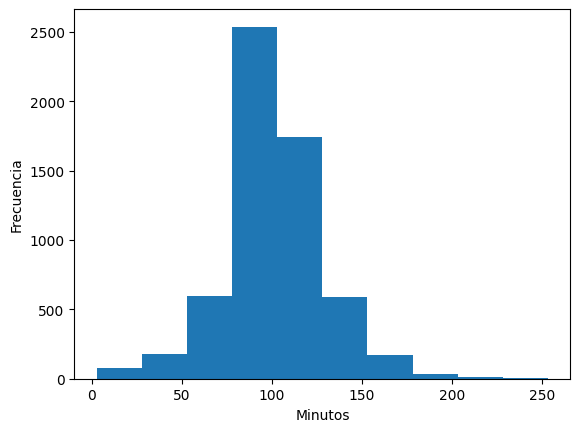

In [26]:
ax = df_movie['minutes'].plot(kind='hist', bins=10)
ax.set_xlabel('Minutos')
ax.set_ylabel('Frecuencia')

In [14]:
# obtener rangos de barras con el método value_counts y el número de bins
df_movie['minutes'].value_counts(bins=10).sort_index()

(2.749, 28.0]       86
(28.0, 53.0]       188
(53.0, 78.0]       619
(78.0, 103.0]     2607
(103.0, 128.0]    1670
(128.0, 153.0]     558
(153.0, 178.0]     163
(178.0, 203.0]      34
(203.0, 228.0]      10
(228.0, 253.0]       5
Name: count, dtype: int64

In [15]:
# Tratar con valores atípicos
df_movie[(df_movie['minutes']<64.8) | (df_movie['minutes']>157.5)].head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,minutes
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,"September 21, 2021",1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...,161
23,s24,Movie,Go! Go! Cory Carson: Chrissy Takes the Wheel,"Alex Woo, Stanley Moore","Maisie Benson, Paul Killam, Kerry Gudjohnsen, ...",NaN,"September 21, 2021",2021,TV-Y,61 min,Children & Family Movies,From arcade games to sled days and hiccup cure...,61
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...,166
45,s46,Movie,My Heroes Were Cowboys,Tyler Greco,NaN,NaN,"September 16, 2021",2021,PG,23 min,Documentaries,Robin Wiltshire's painful childhood was rescue...,23
71,s72,Movie,A StoryBots Space Adventure,David A. Vargas,"Evan Spiridellis, Erin Fitzgerald, Jeff Gill, ...",NaN,"September 14, 2021",2021,TV-Y,13 min,Children & Family Movies,Join the StoryBots and the space travelers of ...,13


##### **Uso de `boxplot` para identificar valores atípicos en datos numéricos**

Text(0.5, 0, 'Duracion (minutos)')

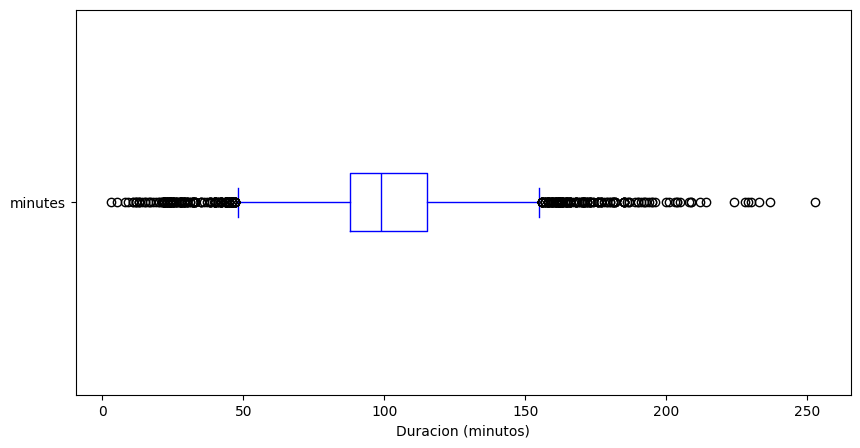

In [31]:
ax = df_movie['minutes'].plot(kind='box', 
                              vert=False, 
                              color='blue',
                              figsize=(10,5))

ax.set_xlabel('Duracion (minutos)')

In [34]:
# Estadística descriptiva general
# IQR = Q3-Q1
min_boxplot = 87 - 1.5*(114 - 87) # Q1 - 1.5*IQR
max_boxplot = 114 + 1.5*(114 - 87) # Q3 + 1.5*IQR

print(min_boxplot)
print(max_boxplot)

46.5
154.5


##### **Uso de `barras` para identificar valores atípicos en datos numéricos**

Text(0, 0.5, 'Frecuencia')

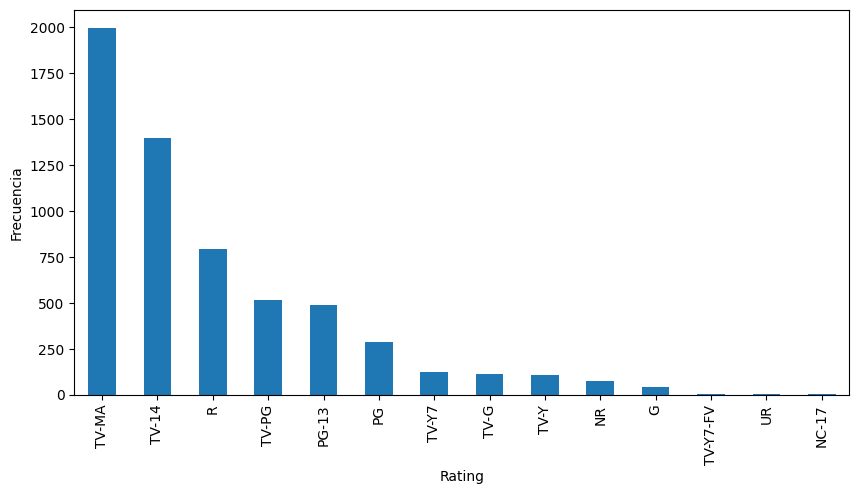

In [38]:
ax = df_movie['rating'].value_counts().plot(kind='bar', figsize=(10,5))
ax.set_xlabel('Rating')
ax.set_ylabel('Frecuencia')

#### **9 - Normalización del texto**

##### Tratamiento de mayúsculas y minúsculas inconsistentes

Vamos a revisar la columna `title`:

In [6]:
df_netflix['title']

0                   Dick Johnson Is Dead
2                              Ganglands
5                          Midnight Mass
6       My Little Pony: A New Generation
7                                Sankofa
                      ...               
8801                             Zinzana
8802                              Zodiac
8804                          Zombieland
8805                                Zoom
8806                              Zubaan
Name: title, Length: 6170, dtype: object

Vamos a imaginar que se nos pidió normalizar todos los nombres de peliculas a `minúsculas`:

In [ ]:
df_movie['movie'] = df_movie['title'].str.lower()

Otra forma de hacerlo:

In [ ]:
df_movie['movie'] = df_movie['title'].apply(lambda x:x.lower())

##### Eliminar espacios en blanco

Vamos a revisar la columna `title`:

In [ ]:
df_netflix['title']

0                   Dick Johnson Is Dead
2                              Ganglands
5                          Midnight Mass
6       My Little Pony: A New Generation
7                                Sankofa
                      ...               
8801                             Zinzana
8802                              Zodiac
8804                          Zombieland
8805                                Zoom
8806                              Zubaan
Name: title, Length: 6170, dtype: object

Vamos a imaginar que se nos pidió eliminar todos los espacios en blanco de la columna `title`:

In [ ]:
df_movie['movie'] = df_movie['title'].str.strip()

Otra forma de hacerlo:

In [ ]:
df_movie['movie'] = df_movie['title'].apply(lambda x:x.strip())

##### Reemplazar simbolos (`:`, `;`, `,`, `"`, `!¡`, `/\`) por espacios en blanco

In [ ]:
df_movie['title'].str.replace('[^\w\s]', '', regex=True)

Otra forma utiizando el método `replace()` y `RegEx`:

In [ ]:
df_movie['title'].replace('[^\w\s]', '', regex=True)